# Emotion Detection Project
## Comparative Study Using Word Embeddings, ML Models, and Encoder-Decoder RNNs

In [ ]:
!pip install datasets gensim fasttext xgboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout,
                                      Bidirectional, RepeatVector, Input)
from tensorflow.keras.callbacks import EarlyStopping

# Embeddings
from gensim.models import Word2Vec
import fasttext

# Dataset
from datasets import load_dataset

print("All imports successful!")

All imports successful!


---
# Phase 1: Data Collection and Loading

In [ ]:
dataset = load_dataset("dair-ai/emotion")
print(dataset)
emotion_names = dataset["train"].features["label"].names
print("\nEmotion classes:", emotion_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Emotion classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
df = pd.DataFrame(dataset["train"])
df["emotion"] = df["label"].map(dict(enumerate(emotion_names)))
print(f"Total samples: {len(df)}")
df.head(10)

Total samples: 16000


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love


---
## Exploratory Data Analysis

=== Class Distribution ===
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


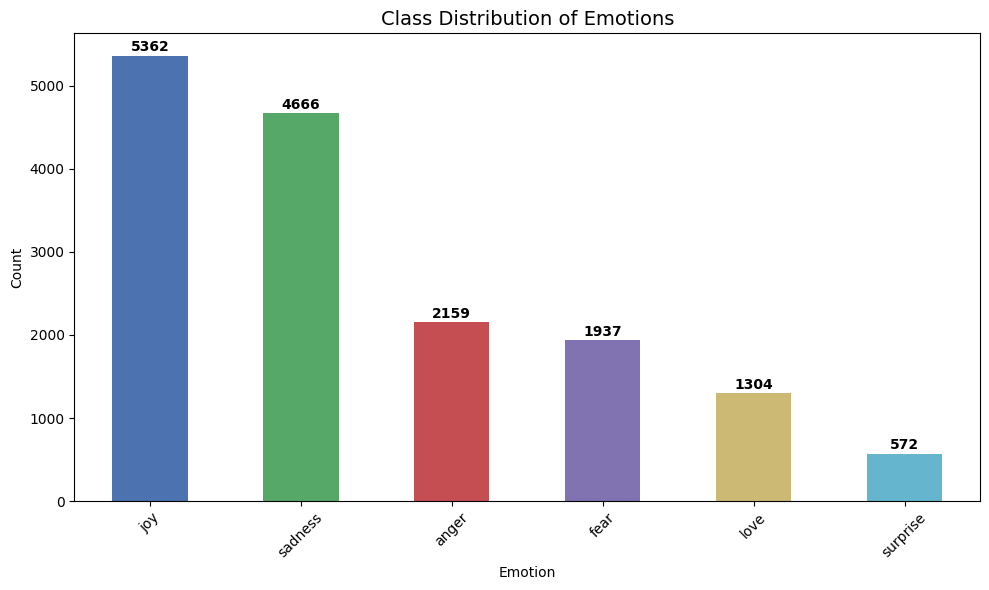

In [ ]:
# Class distribution
print("=== Class Distribution ===")
class_counts = df["emotion"].value_counts()
print(class_counts)

plt.figure(figsize=(10, 6))
ax = class_counts.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD'])
plt.title("Class Distribution of Emotions", fontsize=14)
plt.xlabel("Emotion")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

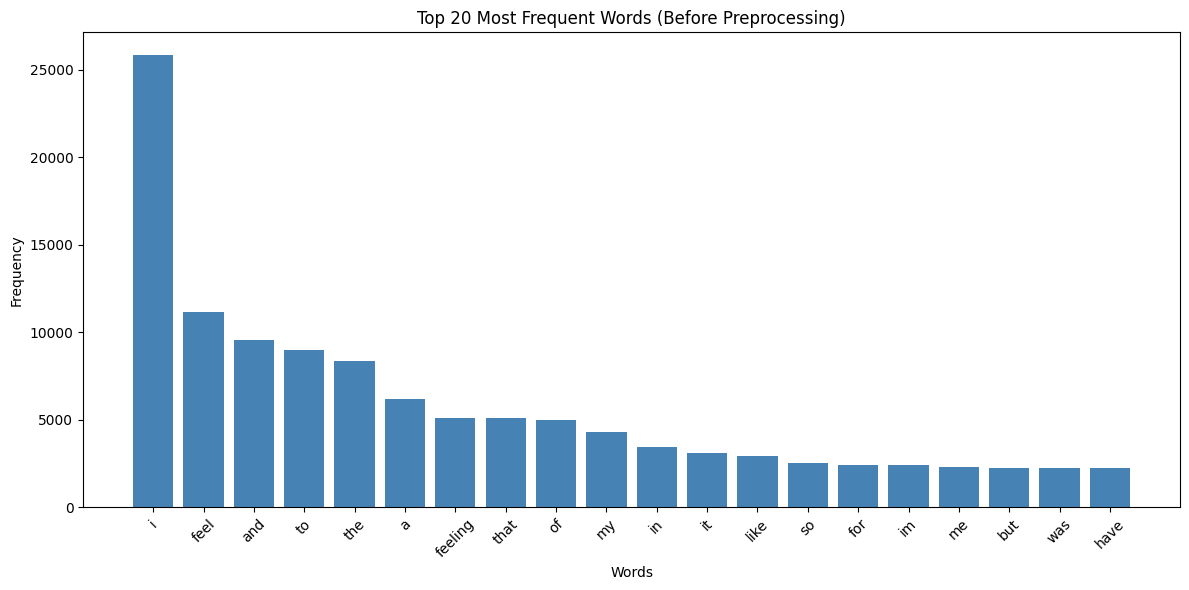

In [ ]:
# Word frequency analysis (before preprocessing)
all_words = " ".join(df["text"]).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)
words = [w for w, f in top_words]
freqs = [f for w, f in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, freqs, color='steelblue')
plt.title("Top 20 Most Frequent Words (Before Preprocessing)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

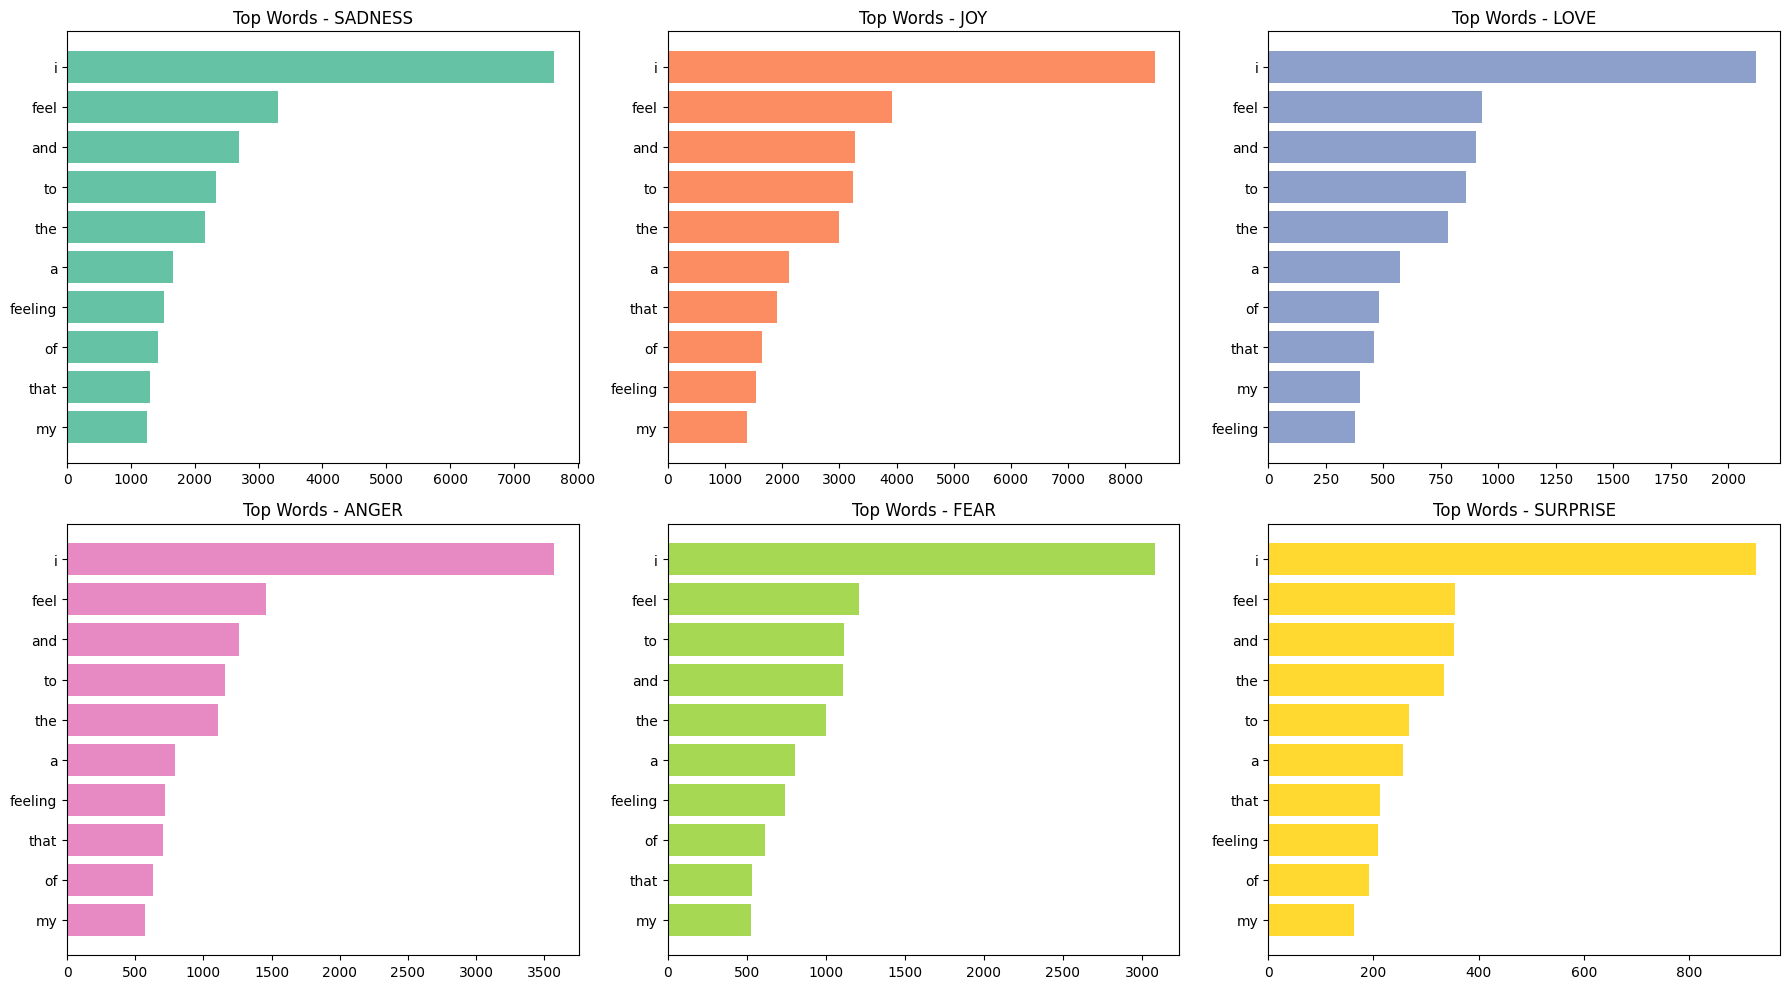

In [ ]:
# Emotion-wise keyword visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, emotion in enumerate(emotion_names):
    emotion_text = " ".join(df[df["emotion"] == emotion]["text"])
    freq = Counter(emotion_text.split())
    top = freq.most_common(10)
    labels = [w for w, c in top]
    counts = [c for w, c in top]
    axes[idx].barh(labels, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f"Top Words - {emotion.upper()}")
    axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()

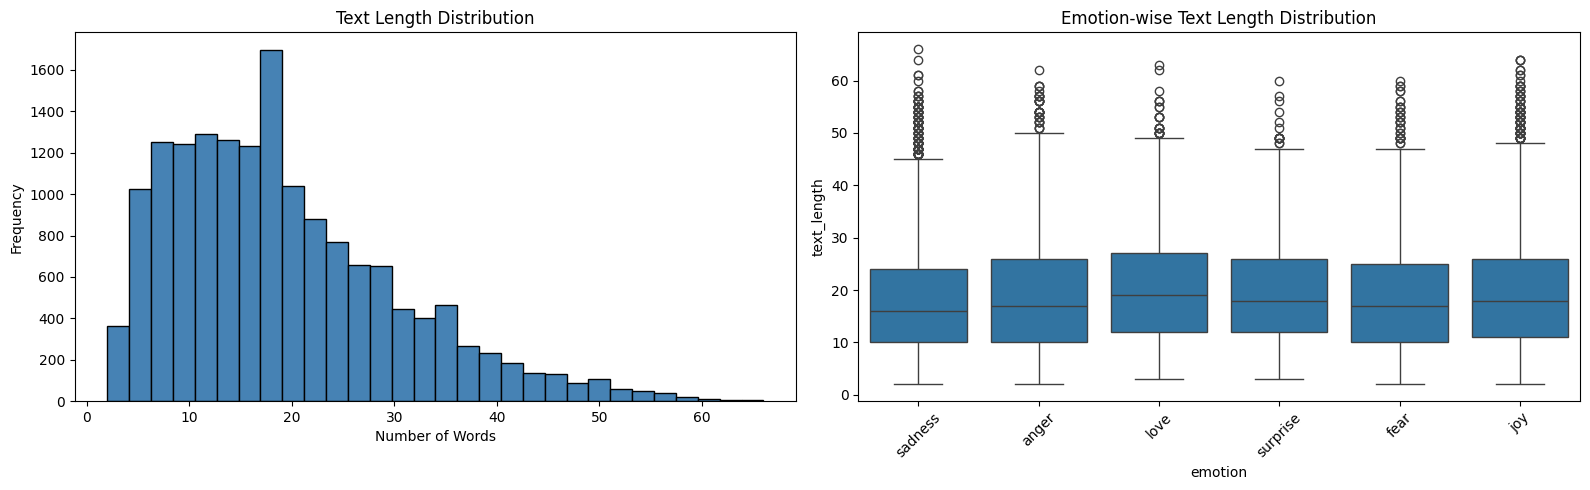

Average text length: 19.2 words
Max text length: 66 words


In [ ]:
# Text length distribution
df["text_length"] = df["text"].apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df["text_length"], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Text Length Distribution")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
sns.boxplot(x="emotion", y="text_length", data=df, ax=axes[1])
axes[1].set_title("Emotion-wise Text Length Distribution")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f"Average text length: {df['text_length'].mean():.1f} words")
print(f"Max text length: {df['text_length'].max()} words")

---
# Phase 1b: Text Preprocessing

In [ ]:
# Keep emotionally important words
emotion_keep_words = {'not', 'no', 'never', 'very', 'so', 'too', 'more', 'most',
                      'really', 'just', 'only', 'still', 'always', 'nothing',
                      'nobody', 'hardly', 'against', 'without'}

stop_words = set(stopwords.words('english')) - emotion_keep_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)
print("Before vs After preprocessing:")
print(df[["text", "clean_text"]].head(5).to_string())

Before vs After preprocessing:
                                                                                                           text                                                               clean_text
0                                                                                       i didnt feel humiliated                                                    didnt feel humiliated
1  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake  go feeling so hopeless so damned hopeful just around someone care awake
2                                                              im grabbing a minute to post i feel greedy wrong                                im grabbing minute post feel greedy wrong
3                  i am ever feeling nostalgic about the fireplace i will know that it is still on the property                     ever feeling nostalgic fireplace know still property
4                                           

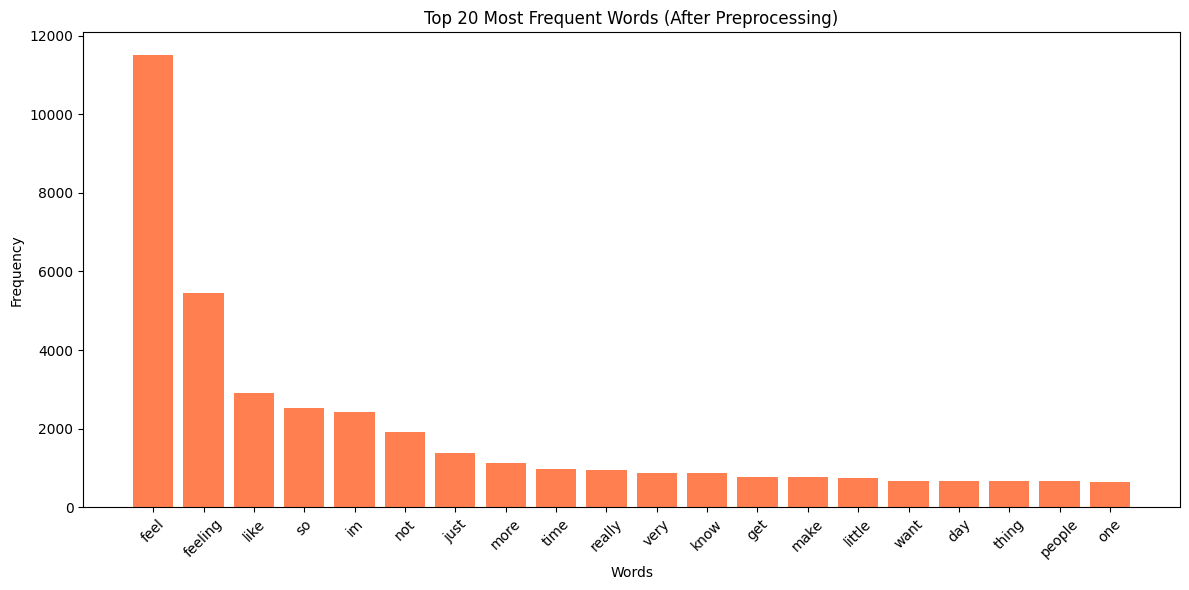

In [ ]:
# Word frequency after preprocessing
all_words_clean = " ".join(df["clean_text"]).split()
word_freq_clean = Counter(all_words_clean)
top_words_clean = word_freq_clean.most_common(20)
words_c = [w for w, f in top_words_clean]
freqs_c = [f for w, f in top_words_clean]

plt.figure(figsize=(12, 6))
plt.bar(words_c, freqs_c, color='coral')
plt.title("Top 20 Most Frequent Words (After Preprocessing)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# Phase 1c: Data Split (70/15/15)

In [ ]:
# 70/15/15 split as required by problem statement
X_temp, X_test_text, y_temp, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.15, random_state=42, stratify=df['label']
)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765, random_state=42, stratify=y_temp
)

# Convert to numpy arrays to prevent index misalignment
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)
X_train_text = X_train_text.reset_index(drop=True)
X_val_text = X_val_text.reset_index(drop=True)
X_test_text = X_test_text.reset_index(drop=True)

print(f"Training set:   {len(X_train_text)} samples ({len(X_train_text)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val_text)} samples ({len(X_val_text)/len(df)*100:.1f}%)")
print(f"Test set:       {len(X_test_text)} samples ({len(X_test_text)/len(df)*100:.1f}%)")
print(f"y_train distribution: {np.bincount(y_train)}")

Training set:   11199 samples (70.0%)
Validation set: 2401 samples (15.0%)
Test set:       2400 samples (15.0%)
y_train distribution: [3266 3753  913 1511 1356  400]


---
# Phase 2: Embedding Generation
## Traditional Embeddings: BoW and TF-IDF

In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Bag of Words
bow = CountVectorizer(max_features=10000)
X_train_bow = bow.fit_transform(X_train_text)
X_val_bow = bow.transform(X_val_text)
X_test_bow = bow.transform(X_test_text)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"BoW shape:    {X_train_bow.shape}")

TF-IDF shape: (11199, 10000)
BoW shape:    (11199, 10000)


## Dense Embeddings: Word2Vec, GloVe, FastText

In [ ]:
# Word2Vec
tokenized_text = [text.split() for text in df["clean_text"]]
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=2, workers=4)
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")

def document_vector_w2v(doc):
    words = doc.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_w2v = np.array([document_vector_w2v(t) for t in X_train_text])
X_val_w2v = np.array([document_vector_w2v(t) for t in X_val_text])
X_test_w2v = np.array([document_vector_w2v(t) for t in X_test_text])
print(f"Word2Vec vectors shape: {X_train_w2v.shape}")

Word2Vec vocabulary size: 6650
Word2Vec vectors shape: (11199, 100)


In [ ]:
# GloVe
!wget -q https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q -o glove.6B.zip

embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs
print(f"Loaded {len(embeddings_index)} GloVe word vectors")

def document_vector_glove(doc):
    words = doc.split()
    vectors = [embeddings_index[w] for w in words if w in embeddings_index]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_glove = np.array([document_vector_glove(t) for t in X_train_text])
X_val_glove = np.array([document_vector_glove(t) for t in X_val_text])
X_test_glove = np.array([document_vector_glove(t) for t in X_test_text])
print(f"GloVe vectors shape: {X_train_glove.shape}")

Loaded 400000 GloVe word vectors
GloVe vectors shape: (11199, 100)


In [ ]:
# FastText
with open("fasttext_train.txt", "w", encoding="utf-8") as f:
    for text in df["clean_text"]:
        f.write(text + "\n")

fasttext_model = fasttext.train_unsupervised("fasttext_train.txt", model='skipgram', dim=100)
print("FastText model trained!")

def document_vector_ft(doc):
    words = doc.split()
    vectors = [fasttext_model.get_word_vector(w) for w in words]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_ft = np.array([document_vector_ft(t) for t in X_train_text])
X_val_ft = np.array([document_vector_ft(t) for t in X_val_text])
X_test_ft = np.array([document_vector_ft(t) for t in X_test_text])
print(f"FastText vectors shape: {X_train_ft.shape}")

FastText model trained!
FastText vectors shape: (11199, 100)


---
# Phase 3: Traditional ML Classification

In [ ]:
all_results = {}

# ===== TF-IDF Models =====
print("=" * 60)
print("TF-IDF MODELS")
print("=" * 60)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
acc = accuracy_score(y_test, nb_tfidf.predict(X_test_tfidf))
all_results["TF-IDF + Naive Bayes"] = acc
print(f"Naive Bayes:         {acc:.4f}")

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
acc = accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf))
all_results["TF-IDF + Logistic Regression"] = acc
print(f"Logistic Regression: {acc:.4f}")

svm_tfidf = LinearSVC()
svm_tfidf.fit(X_train_tfidf, y_train)
acc = accuracy_score(y_test, svm_tfidf.predict(X_test_tfidf))
all_results["TF-IDF + SVM"] = acc
print(f"SVM:                 {acc:.4f}")

xgb_model = XGBClassifier(objective='multi:softmax', num_class=6,
                            n_estimators=200, max_depth=6,
                            learning_rate=0.1, random_state=42,
                            eval_metric='mlogloss')
xgb_model.fit(X_train_tfidf, y_train)
acc = accuracy_score(y_test, xgb_model.predict(X_test_tfidf))
all_results["TF-IDF + XGBoost"] = acc
print(f"XGBoost:             {acc:.4f}")

# ===== BoW Models =====
print("\n" + "=" * 60)
print("BAG OF WORDS MODELS")
print("=" * 60)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
acc = accuracy_score(y_test, nb_bow.predict(X_test_bow))
all_results["BoW + Naive Bayes"] = acc
print(f"Naive Bayes:         {acc:.4f}")

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
acc = accuracy_score(y_test, lr_bow.predict(X_test_bow))
all_results["BoW + Logistic Regression"] = acc
print(f"Logistic Regression: {acc:.4f}")

svm_bow = LinearSVC()
svm_bow.fit(X_train_bow, y_train)
acc = accuracy_score(y_test, svm_bow.predict(X_test_bow))
all_results["BoW + SVM"] = acc
print(f"SVM:                 {acc:.4f}")

# ===== Word2Vec Models =====
print("\n" + "=" * 60)
print("WORD2VEC MODELS")
print("=" * 60)

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)
acc = accuracy_score(y_test, lr_w2v.predict(X_test_w2v))
all_results["Word2Vec + Logistic Regression"] = acc
print(f"Logistic Regression: {acc:.4f}")

svm_w2v = LinearSVC()
svm_w2v.fit(X_train_w2v, y_train)
acc = accuracy_score(y_test, svm_w2v.predict(X_test_w2v))
all_results["Word2Vec + SVM"] = acc
print(f"SVM:                 {acc:.4f}")

# ===== GloVe Models =====
print("\n" + "=" * 60)
print("GLOVE MODELS")
print("=" * 60)

lr_glove = LogisticRegression(max_iter=1000)
lr_glove.fit(X_train_glove, y_train)
acc = accuracy_score(y_test, lr_glove.predict(X_test_glove))
all_results["GloVe + Logistic Regression"] = acc
print(f"Logistic Regression: {acc:.4f}")

svm_glove = LinearSVC()
svm_glove.fit(X_train_glove, y_train)
acc = accuracy_score(y_test, svm_glove.predict(X_test_glove))
all_results["GloVe + SVM"] = acc
print(f"SVM:                 {acc:.4f}")

rf_glove = RandomForestClassifier(n_estimators=100, random_state=42)
rf_glove.fit(X_train_glove, y_train)
acc = accuracy_score(y_test, rf_glove.predict(X_test_glove))
all_results["GloVe + Random Forest"] = acc
print(f"Random Forest:       {acc:.4f}")

# ===== FastText Models =====
print("\n" + "=" * 60)
print("FASTTEXT MODELS")
print("=" * 60)

lr_ft = LogisticRegression(max_iter=1000)
lr_ft.fit(X_train_ft, y_train)
acc = accuracy_score(y_test, lr_ft.predict(X_test_ft))
all_results["FastText + Logistic Regression"] = acc
print(f"Logistic Regression: {acc:.4f}")

svm_ft = LinearSVC()
svm_ft.fit(X_train_ft, y_train)
acc = accuracy_score(y_test, svm_ft.predict(X_test_ft))
all_results["FastText + SVM"] = acc
print(f"SVM:                 {acc:.4f}")

rf_ft = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ft.fit(X_train_ft, y_train)
acc = accuracy_score(y_test, rf_ft.predict(X_test_ft))
all_results["FastText + Random Forest"] = acc
print(f"Random Forest:       {acc:.4f}")

TF-IDF MODELS
Naive Bayes:         0.6650
Logistic Regression: 0.8592
SVM:                 0.8942
XGBoost:             0.8642

BAG OF WORDS MODELS
Naive Bayes:         0.7796
Logistic Regression: 0.8904
SVM:                 0.8883

WORD2VEC MODELS
Logistic Regression: 0.3588
SVM:                 0.4037

GLOVE MODELS
Logistic Regression: 0.5842
SVM:                 0.5721
Random Forest:       0.5129

FASTTEXT MODELS
Logistic Regression: 0.3583
SVM:                 0.3900
Random Forest:       0.3933


---
# Phase 4: Deep Learning Models
## Tokenization and Sequence Preparation

In [ ]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_text), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post')

print(f"Train sequences: {X_train_seq.shape}")
print(f"Val sequences:   {X_val_seq.shape}")
print(f"Test sequences:  {X_test_seq.shape}")

Vocabulary size: 10000
Train sequences: (11199, 100)
Val sequences:   (2401, 100)
Test sequences:  (2400, 100)


In [ ]:
EMBED_DIM = 100

# GloVe embedding matrix
glove_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            glove_matrix[i] = vec
print(f"GloVe coverage: {np.count_nonzero(glove_matrix.sum(axis=1))}/{vocab_size} words")

# Word2Vec embedding matrix
w2v_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in w2v_model.wv:
        w2v_matrix[i] = w2v_model.wv[word]
print(f"Word2Vec coverage: {np.count_nonzero(w2v_matrix.sum(axis=1))}/{vocab_size} words")

# FastText embedding matrix
ft_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        ft_matrix[i] = fasttext_model.get_word_vector(word)
print(f"FastText coverage: {np.count_nonzero(ft_matrix.sum(axis=1))}/{vocab_size} words")

GloVe coverage: 9513/10000 words
Word2Vec coverage: 6650/10000 words
FastText coverage: 9944/10000 words


In [ ]:
# Common EarlyStopping callback
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

## LSTM (Trainable Embeddings)

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                               validation_data=(X_val_seq, y_val), callbacks=[early_stop])

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test)
all_results["BiLSTM"] = lstm_acc
print(f"\n=== BiLSTM Test Accuracy: {lstm_acc:.4f} ===")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.5618 - loss: 1.1558 - val_accuracy: 0.8342 - val_loss: 0.4842
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 161ms/step - accuracy: 0.9090 - loss: 0.2623 - val_accuracy: 0.8921 - val_loss: 0.2986
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.9622 - loss: 0.1053 - val_accuracy: 0.9009 - val_loss: 0.3221
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 52s 150ms/step - accuracy: 0.9759 - loss: 0.0676 - val_accuracy: 0.8921 - val_loss: 0.3624
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 52s 150ms/step - accuracy: 0.9810 - loss: 0.0535 - val_accuracy: 0.8909 - val_loss: 0.4524
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.9846 - loss: 0.0476 - val_accuracy: 0.8905 - val_loss: 0.4552
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 52s 150ms/step - accuracy: 0.9860 - loss: 0.0412 - val_accuracy: 0.8788 - val_loss: 0.5458
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.9906 - loss: 0

## GloVe + Bidirectional LSTM

In [ ]:
glove_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, weights=[glove_matrix],
              input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
glove_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_glove_lstm = glove_lstm.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                                     validation_data=(X_val_seq, y_val), callbacks=[early_stop])

glove_lstm_loss, glove_lstm_acc = glove_lstm.evaluate(X_test_seq, y_test)
all_results["GloVe + BiLSTM"] = glove_lstm_acc
print(f"\n=== GloVe + BiLSTM Accuracy: {glove_lstm_acc:.4f} ===")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.5425 - loss: 1.2111 - val_accuracy: 0.7680 - val_loss: 0.6935
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 144ms/step - accuracy: 0.8580 - loss: 0.4139 - val_accuracy: 0.8896 - val_loss: 0.3208
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 154ms/step - accuracy: 0.9286 - loss: 0.1995 - val_accuracy: 0.8996 - val_loss: 0.2939
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.9520 - loss: 0.1316 - val_accuracy: 0.9063 - val_loss: 0.2700
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.9639 - loss: 0.0966 - val_accuracy: 0.9050 - val_loss: 0.2843
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.9724 - loss: 0.0752 - val_accuracy: 0.9063 - val_loss: 0.2820
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - accuracy: 0.9802 - loss: 0.0565 - val_accuracy: 0.9167 - val_loss: 0.3020
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.9833 - loss: 0

## GloVe + Bidirectional GRU

In [ ]:
glove_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, weights=[glove_matrix],
              input_length=MAX_LEN, trainable=True),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
glove_gru.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_glove_gru = glove_gru.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                                    validation_data=(X_val_seq, y_val), callbacks=[early_stop])

glove_gru_loss, glove_gru_acc = glove_gru.evaluate(X_test_seq, y_test)
all_results["GloVe + BiGRU"] = glove_gru_acc
print(f"\n=== GloVe + BiGRU Accuracy: {glove_gru_acc:.4f} ===")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 64s 171ms/step - accuracy: 0.5596 - loss: 1.1716 - val_accuracy: 0.7868 - val_loss: 0.6007
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.8771 - loss: 0.3508 - val_accuracy: 0.9017 - val_loss: 0.2461
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.9370 - loss: 0.1655 - val_accuracy: 0.9055 - val_loss: 0.2298
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.9526 - loss: 0.1175 - val_accuracy: 0.9105 - val_loss: 0.2210
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.9657 - loss: 0.0875 - val_accuracy: 0.9134 - val_loss: 0.2465
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7879 - loss: 0.5773

=== GloVe + BiGRU Accuracy: 0.7879 ===


## Word2Vec + Bidirectional LSTM

In [ ]:
w2v_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, weights=[w2v_matrix],
              input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
w2v_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v_lstm = w2v_lstm.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                                  validation_data=(X_val_seq, y_val), callbacks=[early_stop])

w2v_lstm_loss, w2v_lstm_acc = w2v_lstm.evaluate(X_test_seq, y_test)
all_results["Word2Vec + BiLSTM"] = w2v_lstm_acc
print(f"\n=== Word2Vec + BiLSTM Accuracy: {w2v_lstm_acc:.4f} ===")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 147ms/step - accuracy: 0.3534 - loss: 1.5685 - val_accuracy: 0.4931 - val_loss: 1.3483
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.7216 - loss: 0.7946 - val_accuracy: 0.8292 - val_loss: 0.4954
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 155ms/step - accuracy: 0.9015 - loss: 0.3025 - val_accuracy: 0.8592 - val_loss: 0.4310
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.9455 - loss: 0.1672 - val_accuracy: 0.8496 - val_loss: 0.5099
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.9654 - loss: 0.1044 - val_accuracy: 0.8730 - val_loss: 0.4342
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4758 - loss: 1.3604

=== Word2Vec + BiLSTM Accuracy: 0.4758 ===


## FastText + Bidirectional LSTM

In [ ]:
ft_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, weights=[ft_matrix],
              input_length=MAX_LEN, trainable=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
ft_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_ft_lstm = ft_lstm.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                                validation_data=(X_val_seq, y_val), callbacks=[early_stop])

ft_lstm_loss, ft_lstm_acc = ft_lstm.evaluate(X_test_seq, y_test)
all_results["FastText + BiLSTM"] = ft_lstm_acc
print(f"\n=== FastText + BiLSTM Accuracy: {ft_lstm_acc:.4f} ===")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 146ms/step - accuracy: 0.4451 - loss: 1.4027 - val_accuracy: 0.6747 - val_loss: 0.8790
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.8267 - loss: 0.5285 - val_accuracy: 0.8567 - val_loss: 0.4620
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.9296 - loss: 0.2166 - val_accuracy: 0.8730 - val_loss: 0.4035
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 144ms/step - accuracy: 0.9609 - loss: 0.1251 - val_accuracy: 0.8809 - val_loss: 0.3876
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.9694 - loss: 0.0865 - val_accuracy: 0.8684 - val_loss: 0.4535
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6767 - loss: 0.8912

=== FastText + BiLSTM Accuracy: 0.6767 ===


---
# Phase 5: Encoder-Decoder RNN Architecture
## (Required by Problem Statement)

In [ ]:
# True Encoder-Decoder RNN Architecture
# Encoder: Bidirectional GRU encodes input sequence into context vector
# Decoder: Bidirectional GRU decodes context vector for classification

# --- Encoder ---
encoder_input = Input(shape=(MAX_LEN,), name='encoder_input')
encoder_embedding = Embedding(input_dim=vocab_size, output_dim=100,
                               weights=[glove_matrix],
                               input_length=MAX_LEN, trainable=True,
                               name='encoder_embedding')(encoder_input)
encoder_gru = Bidirectional(GRU(128, return_sequences=False), name='encoder_gru')(encoder_embedding)
encoder_dropout = Dropout(0.3, name='encoder_dropout')(encoder_gru)

# --- Decoder ---
decoder_repeat = RepeatVector(MAX_LEN, name='repeat_context')(encoder_dropout)
decoder_gru = Bidirectional(GRU(64, return_sequences=False), name='decoder_gru')(decoder_repeat)
decoder_dropout = Dropout(0.3, name='decoder_dropout')(decoder_gru)
decoder_dense = Dense(64, activation='relu', name='decoder_dense')(decoder_dropout)
output = Dense(6, activation='softmax', name='output')(decoder_dense)

enc_dec_model = Model(inputs=encoder_input, outputs=output, name='Encoder_Decoder_RNN')
enc_dec_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
enc_dec_model.summary()

history_enc_dec = enc_dec_model.fit(X_train_seq, y_train, epochs=20, batch_size=32,
                                     validation_data=(X_val_seq, y_val), callbacks=[early_stop])

enc_dec_loss, enc_dec_acc = enc_dec_model.evaluate(X_test_seq, y_test)
all_results["Encoder-Decoder RNN"] = enc_dec_acc
print(f"\n=== Encoder-Decoder RNN Accuracy: {enc_dec_acc:.4f} ===")

Model: "Encoder_Decoder_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_embedding (Embedding)   │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_gru (Bidirectional)     │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_context (RepeatVector)   │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_gru (Bidirectional)     │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,308,934 (4.99 MB)

 Trainable params: 1,308,934 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 193s 529ms/step - accuracy: 0.5880 - loss: 1.1094 - val_accuracy: 0.8117 - val_loss: 0.5385
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 201s 527ms/step - accuracy: 0.8862 - loss: 0.3188 - val_accuracy: 0.9017 - val_loss: 0.2551
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 201s 526ms/step - accuracy: 0.9345 - loss: 0.1713 - val_accuracy: 0.9146 - val_loss: 0.2285
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 521ms/step - accuracy: 0.9529 - loss: 0.1204 - val_accuracy: 0.9096 - val_loss: 0.2358
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 180s 513ms/step - accuracy: 0.9599 - loss: 0.0945 - val_accuracy: 0.9175 - val_loss: 0.2482
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 519ms/step - accuracy: 0.9704 - loss: 0.0769 - val_accuracy: 0.9196 - val_loss: 0.2424
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 180s 515ms/step - accuracy: 0.9762 - loss: 0.0629 - val_accuracy: 0.9167 - val_loss: 0.2836
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.9834 -

---
# Phase 6: Comprehensive Evaluation

FINAL MODEL COMPARISON


,Model,Accuracy
0,Encoder-Decoder RNN,0.920417
1,GloVe + BiLSTM,0.903750
2,BiLSTM,0.895417
3,TF-IDF + SVM,0.894167
4,BoW + Logistic Regression,0.890417
5,BoW + SVM,0.888333
6,TF-IDF + XGBoost,0.864167
7,TF-IDF + Logistic Regression,0.859167
8,GloVe + BiGRU,0.787917
9,BoW + Naive Bayes,0.779583


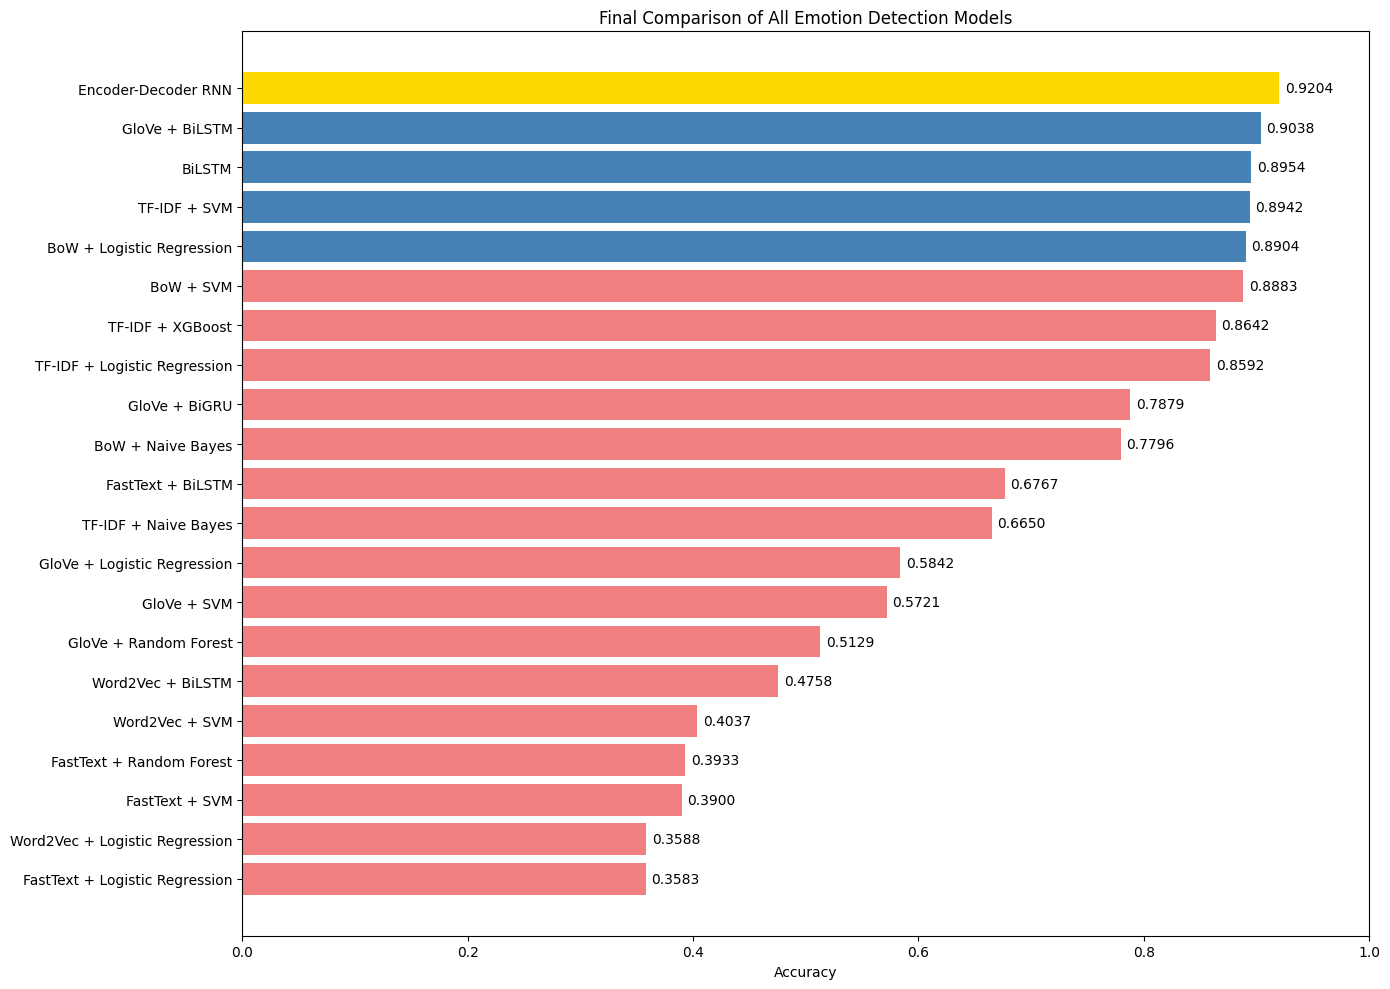


Best Model: Encoder-Decoder RNN — 0.9204 accuracy


In [ ]:
# Final results comparison
results_df = pd.DataFrame({
    "Model": list(all_results.keys()),
    "Accuracy": list(all_results.values())
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
display(results_df)

plt.figure(figsize=(14, 10))
colors = ['gold' if i == 0 else ('steelblue' if i < 5 else 'lightcoral') for i in range(len(results_df))]
plt.barh(results_df["Model"], results_df["Accuracy"], color=colors)
plt.xlabel("Accuracy")
plt.title("Final Comparison of All Emotion Detection Models")
plt.gca().invert_yaxis()
plt.xlim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest Model: {best_model_name} — {results_df.iloc[0]['Accuracy']:.4f} accuracy")

In [ ]:
# Detailed evaluation — Best Deep Learning Model (Encoder-Decoder RNN)
print("=" * 60)
print("DETAILED EVALUATION: Encoder-Decoder RNN")
print("=" * 60)

y_pred_probs = enc_dec_model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_classes, target_names=emotion_names))

macro_f1 = f1_score(y_test, y_pred_classes, average='macro')
weighted_f1 = f1_score(y_test, y_pred_classes, average='weighted')
macro_precision = precision_score(y_test, y_pred_classes, average='macro')
macro_recall = recall_score(y_test, y_pred_classes, average='macro')

print(f"Macro Precision:  {macro_precision:.4f}")
print(f"Macro Recall:     {macro_recall:.4f}")
print(f"Macro F1 Score:   {macro_f1:.4f}")
print(f"Weighted F1:      {weighted_f1:.4f}")

DETAILED EVALUATION: Encoder-Decoder RNN
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step

=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       700
         joy       0.93      0.94      0.94       804
        love       0.80      0.79      0.79       196
       anger       0.95      0.91      0.93       324
        fear       0.90      0.88      0.89       290
    surprise       0.74      0.90      0.81        86

    accuracy                           0.92      2400
   macro avg       0.88      0.89      0.89      2400
weighted avg       0.92      0.92      0.92      2400

Macro Precision:  0.8803
Macro Recall:     0.8949
Macro F1 Score:   0.8863
Weighted F1:      0.9207


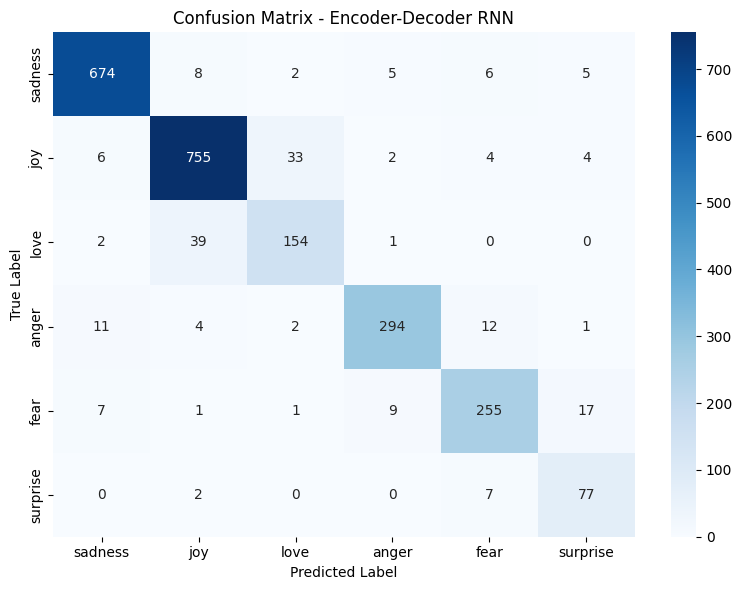

In [ ]:
# Confusion Matrix - Encoder-Decoder RNN
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.title("Confusion Matrix - Encoder-Decoder RNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

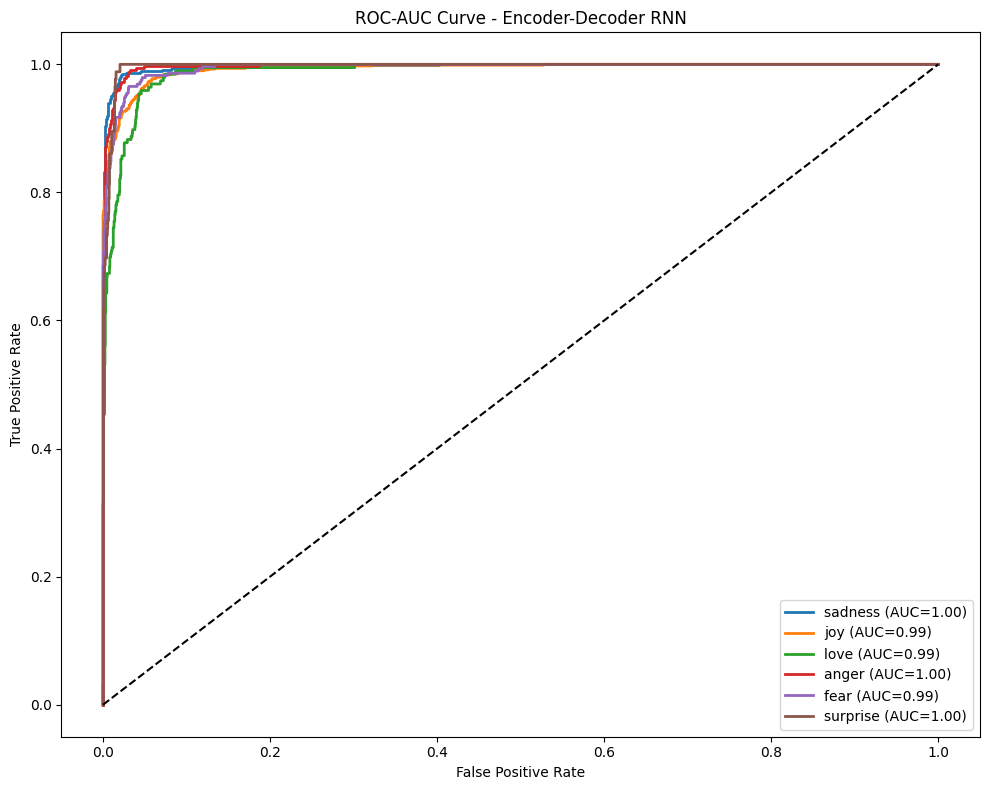

In [ ]:
# ROC-AUC Curve - Encoder-Decoder RNN
num_classes = 6
y_test_bin = label_binarize(y_test, classes=range(num_classes))

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{emotion_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Encoder-Decoder RNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

DETAILED EVALUATION: GloVe + BiGRU
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.85      0.90      0.87       700
         joy       0.78      0.92      0.84       804
        love       0.79      0.19      0.30       196
       anger       0.69      0.86      0.77       324
        fear       0.82      0.70      0.75       290
    surprise       0.75      0.03      0.07        86

    accuracy                           0.79      2400
   macro avg       0.78      0.60      0.60      2400
weighted avg       0.79      0.79      0.76      2400



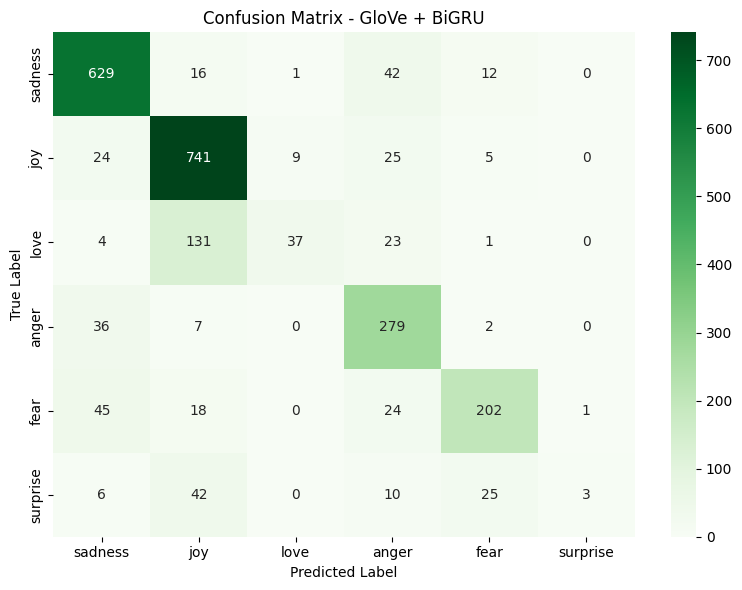

In [ ]:
# Detailed evaluation — GloVe + BiGRU
print("=" * 60)
print("DETAILED EVALUATION: GloVe + BiGRU")
print("=" * 60)

y_pred_gru_probs = glove_gru.predict(X_test_seq)
y_pred_gru_classes = np.argmax(y_pred_gru_probs, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_gru_classes, target_names=emotion_names))

# Confusion Matrix
cm_gru = confusion_matrix(y_test, y_pred_gru_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.title("Confusion Matrix - GloVe + BiGRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

---
# Phase 7: Save Models & Predict Emotions

In [ ]:
import pickle

enc_dec_model.save("encoder_decoder_emotion_model.h5")
glove_gru.save("glove_bigru_emotion_model.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Models and tokenizer saved successfully!")

Models and tokenizer saved successfully!


In [ ]:
def predict_emotion(text, model=enc_dec_model, model_name="Encoder-Decoder RNN"):
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)
    emotion_id = np.argmax(pred)
    emotion_name = emotion_names[emotion_id]
    confidence = np.max(pred)

    print(f"Text:             {text}")
    print(f"Clean:            {clean}")
    print(f"Model:            {model_name}")
    print(f"Predicted Emotion:{emotion_name}")
    print(f"Confidence:       {confidence*100:.2f}%")
    print(f"All probabilities:{dict(zip(emotion_names, [f'{p*100:.1f}%' for p in pred[0]]))}")
    print()

In [ ]:
# Test predictions
print("=" * 60)
print("PREDICTIONS - Encoder-Decoder RNN")
print("=" * 60)

predict_emotion("I am feeling really happy and excited")
predict_emotion("I feel hopeless and empty inside")
predict_emotion("I am so scared and nervous")
predict_emotion("I love you so much")
predict_emotion("I am so angry and frustrated")
predict_emotion("Oh wow I cannot believe this happened")
predict_emotion("I am feeling lonely and depressed")
predict_emotion("This is the best day of my life")
predict_emotion("I am disgusted and furious")
predict_emotion("I feel so grateful and blessed")

PREDICTIONS - Encoder-Decoder RNN
Text:             I am feeling really happy and excited
Clean:            feeling really happy excited
Model:            Encoder-Decoder RNN
Predicted Emotion:joy
Confidence:       100.00%
All probabilities:{'sadness': '0.0%', 'joy': '100.0%', 'love': '0.0%', 'anger': '0.0%', 'fear': '0.0%', 'surprise': '0.0%'}

Text:             I feel hopeless and empty inside
Clean:            feel hopeless empty inside
Model:            Encoder-Decoder RNN
Predicted Emotion:sadness
Confidence:       99.99%
All probabilities:{'sadness': '100.0%', 'joy': '0.0%', 'love': '0.0%', 'anger': '0.0%', 'fear': '0.0%', 'surprise': '0.0%'}

Text:             I am so scared and nervous
Clean:            so scared nervous
Model:            Encoder-Decoder RNN
Predicted Emotion:fear
Confidence:       99.94%
All probabilities:{'sadness': '0.0%', 'joy': '0.0%', 'love': '0.0%', 'anger': '0.0%', 'fear': '99.9%', 'surprise': '0.0%'}

Text:             I love you so much
Clean:        